# Bitmask as a Data Container

Beyond tile indexing, the QBTiles bitmask structure can serve as a **spatial data compression format**.

The key insight: when spatial data is distributed across an irregular grid, traditional formats store both **grid IDs** and **values**. But if the data lives on a quadtree, the bitmask already encodes *where* each value belongs. Grid IDs become zero-cost.

This example demonstrates this with South Korea's 100m population grid (931K cells):
1. Load raw census data and convert grid IDs to coordinates
2. Build a QBT columnar file with `qbt.build()` (one line)
3. Verify and compare file sizes
4. (Optional) Visualize the grid distribution
5. (Advanced) Spatial range query via quadkey prefix

Data source: [Statistics Korea (KOSTAT) 100m population grid, 2021](https://sgis.kostat.go.kr)

## 1. Load raw census data from zip

In [1]:
import os, sys, zipfile, io
import pandas as pd

sys.path.insert(0, os.path.join("..", "..", "src", "python"))
import qbtiles as qbt
import popu_utils

# Read all txt files from zip
zip_path = "pop_100m_epsg5179_2021.zip"
frames = []
with zipfile.ZipFile(zip_path) as zf:
    for name in zf.namelist():
        if name.endswith(".txt"):
            with zf.open(name) as f:
                df_part = pd.read_csv(f, sep='^', header=None,
                                      names=["year", "cell", "code", "popu"],
                                      dtype={"year": str, "cell": str, "code": str, "popu": int})
                frames.append(df_part)

df_raw = pd.concat(frames, ignore_index=True)
print(f"Raw records: {len(df_raw):,}")
df_raw.head()

Raw records: 3,146,430


,year,cell,code,popu
0,2021,가다780670,to_in_001,8
1,2021,가다781673,to_in_001,5
2,2021,가다780672,to_in_001,8
3,2021,가다806646,to_in_001,5
4,2021,가다782673,to_in_001,8


## 2. Convert grid IDs to coordinates and pivot

KOSTAT grid IDs (e.g. `가다780670`) encode position using Korean syllable prefixes for 100km blocks. We convert these to EPSG:5179 projected coordinates, then pivot the data so each grid cell has total/male/female columns.

In [2]:
# Convert grid IDs to x/y coordinates
df_xy = popu_utils.convert_grid_id_to_xy(df_raw, "cell", "100m")
df = pd.concat([df_xy, df_raw[["code", "popu"]]], axis=1)

# Map codes: to_in_001=total, to_in_007=male, to_in_008=female
code_map = {"to_in_001": "total", "to_in_007": "male", "to_in_008": "female"}
df["code"] = df["code"].map(code_map)

# Pivot: one row per grid cell
df_pivot = df.pivot_table(index=["cell_x", "cell_y"], columns="code", values="popu", fill_value=0).reset_index()
df_pivot[["total", "male", "female"]] = df_pivot[["total", "male", "female"]].astype(int)
df_pivot = df_pivot[df_pivot["total"] > 0]
print(f"Grid cells with population: {len(df_pivot):,}")
df_pivot.head()

Grid cells with population: 931,495


code,cell_x,cell_y,female,male,total
0,746950,2001050,13,18,28
1,746950,2001150,0,0,5
2,747050,2000150,0,0,5
3,747050,2001050,5,8,8
5,747150,2000650,5,0,5


## 3. Build QBT columnar file

One call to `qbt.build()`. Quadkey encoding, bitmask serialization, and varint packing are all handled internally.

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

output_path = "pop_korea_100m.qbt.gz"

qbt.build(output_path,
    coords=list(zip(df_pivot["cell_x"], df_pivot["cell_y"])),
    columns={
        "total": df_pivot["total"].tolist(),
        "male": df_pivot["male"].tolist(),
        "female": df_pivot["female"].tolist(),
    },
    cell_size=100, crs=5179)

file_size = os.path.getsize(output_path)
h = qbt.read_qbt_header(output_path)
print(f"File: {output_path} ({file_size:,} bytes, {file_size/1024/1024:.1f} MB)")
print(f"Zoom: {h['zoom']}, CRS: {h['crs']}, Fields: {[f['name'] for f in h['fields']]}")
print(f"Cells: {len(df_pivot):,}")
print(f"Per cell: {file_size/len(df_pivot):.2f} bytes")

File: pop_korea_100m.qbt.gz (1,830,801 bytes, 1.7 MB)
Zoom: 13, CRS: 5179, Fields: ['total', 'male', 'female']
Cells: 931,495
Per cell: 1.97 bytes


## 4. Verify

Read back values and compare with original.

In [4]:
import gzip as gz
from io import BytesIO

h = qbt.read_qbt_header(output_path)
print(f"zoom={h['zoom']}, crs={h['crs']}, fields={[f['name'] for f in h['fields']]}")

raw = gz.decompress(open(output_path, "rb").read())
val_io = BytesIO(raw[h["values_offset"]:])
n = len(df_pivot)

total_sum = sum(qbt.read_varint(val_io) for _ in range(n))
male_sum = sum(qbt.read_varint(val_io) for _ in range(n))
female_sum = sum(qbt.read_varint(val_io) for _ in range(n))

print(f"Read back {n:,} cells")
print(f"Total sum: {total_sum:,} (original: {df_pivot['total'].sum():,})")
print(f"Male sum:  {male_sum:,} (original: {df_pivot['male'].sum():,})")
print(f"Female sum:{female_sum:,} (original: {df_pivot['female'].sum():,})")
print(f"Match: {total_sum == df_pivot['total'].sum() and male_sum == df_pivot['male'].sum()}")

zoom=13, crs=5179, fields=['total', 'male', 'female']


Read back 931,495 cells
Total sum: 50,789,234 (original: 50,789,234)
Male sum:  25,424,242 (original: 25,424,242)
Female sum:25,920,613 (original: 25,920,613)
Match: True


## 5. Size comparison

Compare against Parquet for the same data (931K cells x 3 values).

In [5]:
qb_gz_size = os.path.getsize(output_path)

parquet_path = "pop_korea_100m.parquet"
df_pivot[["cell_x", "cell_y", "total", "male", "female"]].to_parquet(parquet_path, index=False)
parquet_size = os.path.getsize(parquet_path)

parquet_zip_path = "pop_korea_100m_parquet.zip"
with zipfile.ZipFile(parquet_zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(parquet_path)
parquet_zip_size = os.path.getsize(parquet_zip_path)

print(f'{"Format":<25} {"Size":>12} {"Ratio":>12}')
print("-" * 52)
for name, size in [
    ("Parquet", parquet_size),
    ("Parquet + zip", parquet_zip_size),
    ("QBTiles columnar (gzip)", qb_gz_size),
]:
    pct = size / parquet_zip_size * 100
    print(f"{name:<25} {size/1024/1024:>9.1f} MB {pct:>10.0f}%")

os.remove(parquet_path)
os.remove(parquet_zip_path)

Format                            Size        Ratio
----------------------------------------------------
Parquet                         3.6 MB        115%
Parquet + zip                   3.2 MB        100%
QBTiles columnar (gzip)         1.7 MB         55%


## 6. Visualize the grid distribution (optional)

The populated cells form an irregular pattern. Dense in cities, sparse in mountains and coastlines. This sparsity is what makes bitmask encoding effective: empty regions cost zero bits.

Total possible cells (8192x8192): 67,108,864
Occupied cells: 931,495 (1.4%)
Empty cells: 66,177,369 (98.6%)


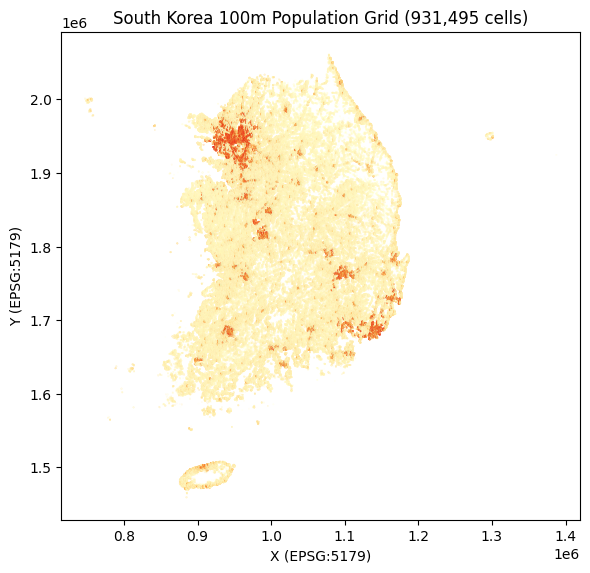

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(6, 10))

# Color by log population for visibility
pop = np.log1p(df_pivot["total"].values)

ax.scatter(df_pivot["cell_x"], df_pivot["cell_y"], s=0.01, c=pop, cmap="YlOrRd", alpha=0.5)
ax.set_aspect("equal")
ax.set_title(f"South Korea 100m Population Grid ({len(df_pivot):,} cells)")
ax.set_xlabel("X (EPSG:5179)")
ax.set_ylabel("Y (EPSG:5179)")

# Stats
total_possible = (819200 // 100) ** 2  # 8192 x 8192
occupancy = len(df_pivot) / total_possible * 100
print(f"Total possible cells (8192x8192): {total_possible:,}")
print(f"Occupied cells: {len(df_pivot):,} ({occupancy:.1f}%)")
print(f"Empty cells: {total_possible - len(df_pivot):,} ({100-occupancy:.1f}%)")

plt.tight_layout()
plt.show()

## 7. Spatial range query via quadkey (advanced)

Quadkey encoding preserves spatial hierarchy. A subregion query reduces to binary search on a sorted array: **O(log N)**.

This step encodes quadkeys explicitly for the spatial query demo. Note that `qbt.build()` in step 3 did this internally — here we do it manually to demonstrate the query mechanism.

In [7]:
origin_x, origin_y = 700000, 1300000
extent = 819200  # 100m * 2^13
zoom = 13

df_pivot["quadkey"] = [
    qbt.encode_custom_quadkey(x, y, zoom, origin_x, origin_y, extent)
    for x, y in zip(df_pivot["cell_x"], df_pivot["cell_y"])
]
print(f"Encoded {len(df_pivot):,} quadkeys")

# Verify round-trip
qk = df_pivot["quadkey"].iloc[0]
x, y = qbt.decode_custom_quadkey(qk, zoom, origin_x, origin_y, extent)
print(f"quadkey {qk} -> ({x}, {y}), match={x == df_pivot['cell_x'].iloc[0]}")

Encoded 931,495 quadkeys
quadkey 244021529 -> (746950, 2001050), match=True


The final table has no grid IDs or coordinates — just a quadkey (which the bitmask will encode implicitly) and the values. This is what gets stored:

In [8]:
# Final table: quadkey encodes position, values follow directly
df_pivot[["quadkey", "total", "male", "female"]].head(10)

code,quadkey,total,male,female
0,244021529,28,18,13
1,244021531,5,0,0
2,244020118,5,0,0
3,244021532,8,8,5
5,244020157,5,0,5
7,244020280,5,0,0
8,244020283,5,0,5
9,244020276,87,60,25
10,244020278,8,5,5
11,244020284,5,5,5


Once decoded into a sorted array, any subregion can be retrieved with `searchsorted`.

Hilbert-curve-based tile IDs (PMTiles) do not share prefixes across zoom levels, so this contiguous-range property is unique to quadkey/Z-order encoding.

Query: zoom-5 tile -> 26,837 cells (2.9%)


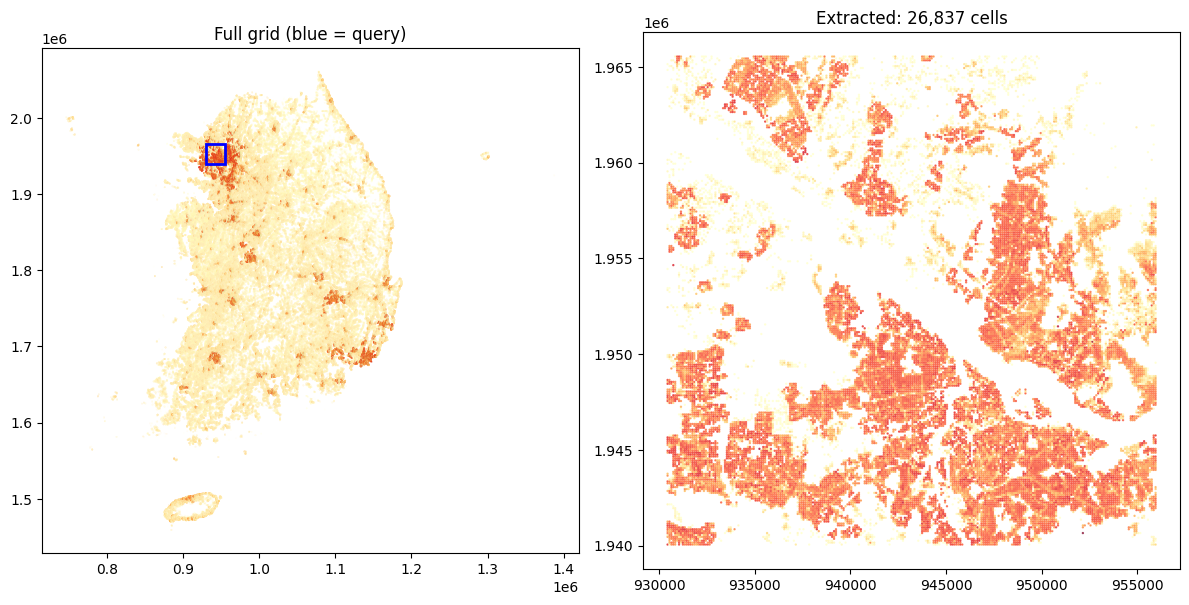

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Sort by quadkey for binary search
df_sorted = df_pivot.sort_values("quadkey").reset_index(drop=True)
qk_arr = np.array(df_sorted["quadkey"].values, dtype=np.int64)
val_arr = np.array(df_sorted[["total", "male", "female"]].values, dtype=np.int32)


def query_subregion(parent_qk_int, parent_zoom):
    """Binary search on sorted quadkey array. O(log N)."""
    shift = 2 * (zoom - parent_zoom)
    qk_min = parent_qk_int << shift
    qk_max = qk_min | ((1 << shift) - 1)
    i0 = np.searchsorted(qk_arr, qk_min)
    i1 = np.searchsorted(qk_arr, qk_max, side="right")
    return qk_arr[i0:i1], val_arr[i0:i1]


def plot_query(parent_qk_int, parent_zoom):
    """Query a subregion and plot full grid vs extracted region."""
    sub_qk, sub_val = query_subregion(parent_qk_int, parent_zoom)
    print(f"Query: zoom-{parent_zoom} tile -> {len(sub_qk):,} cells ({len(sub_qk)/len(qk_arr)*100:.1f}%)")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Left: full grid + query box
    ax1.scatter(df_pivot["cell_x"], df_pivot["cell_y"], s=0.01,
               c=np.log1p(df_pivot["total"].values), cmap="YlOrRd", alpha=0.3)
    tile_size = extent / (2 ** parent_zoom)
    cx, cy = qbt.decode_custom_quadkey(parent_qk_int, parent_zoom, origin_x, origin_y, extent)
    ax1.add_patch(plt.Rectangle((cx - tile_size/2, cy - tile_size/2),
        tile_size, tile_size, linewidth=2, edgecolor="blue", facecolor="none"))
    ax1.set_aspect("equal")
    ax1.set_title("Full grid (blue = query)")

    # Right: extracted subregion
    coords = np.array([qbt.decode_custom_quadkey(int(qk), zoom, origin_x, origin_y, extent) for qk in sub_qk])
    ax2.scatter(coords[:, 0], coords[:, 1], s=0.5,
               c=np.log1p(sub_val[:, 0]), cmap="YlOrRd", alpha=0.7)
    ax2.set_aspect("equal")
    ax2.set_title(f"Extracted: {len(sub_qk):,} cells")

    plt.tight_layout()
    plt.show()


# Query Seoul area (zoom 5 tile)
seoul_qk = qbt.encode_custom_quadkey(950000, 1950000, 5, origin_x, origin_y, extent)
plot_query(seoul_qk, 5)